<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/Machine_Learning/PCAHandsOn_Aisha(11_09).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEPS to perform PCA:
1. Standardize the data
2. Compute the covariance matrix
3. Compute eigen values and eigen vector
4. Sort the eigen values
5. calculate variance explained and cumulative variance
6. select number of Principle Components
7. Interpret the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
digits=load_digits()  #loading the data

In [ ]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [ ]:
digits.target
#each image has 64 values representing pixels respectively(8X8 Image)

array([0, 1, 2, ..., 8, 9, 8])

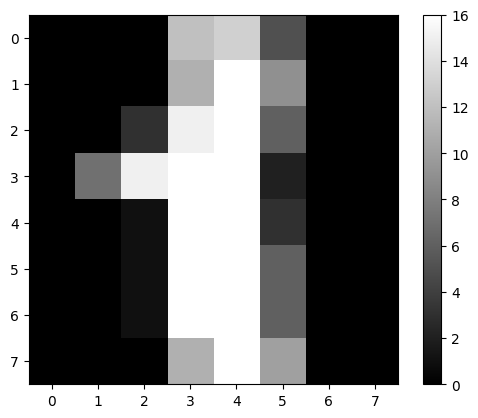

In [ ]:
plt.imshow(digits.images[1],cmap=plt.cm.gray)
#.imshow: display image, converts numerical data into pixel/image format
#[1]: represents the second image(index 1)
plt.colorbar()

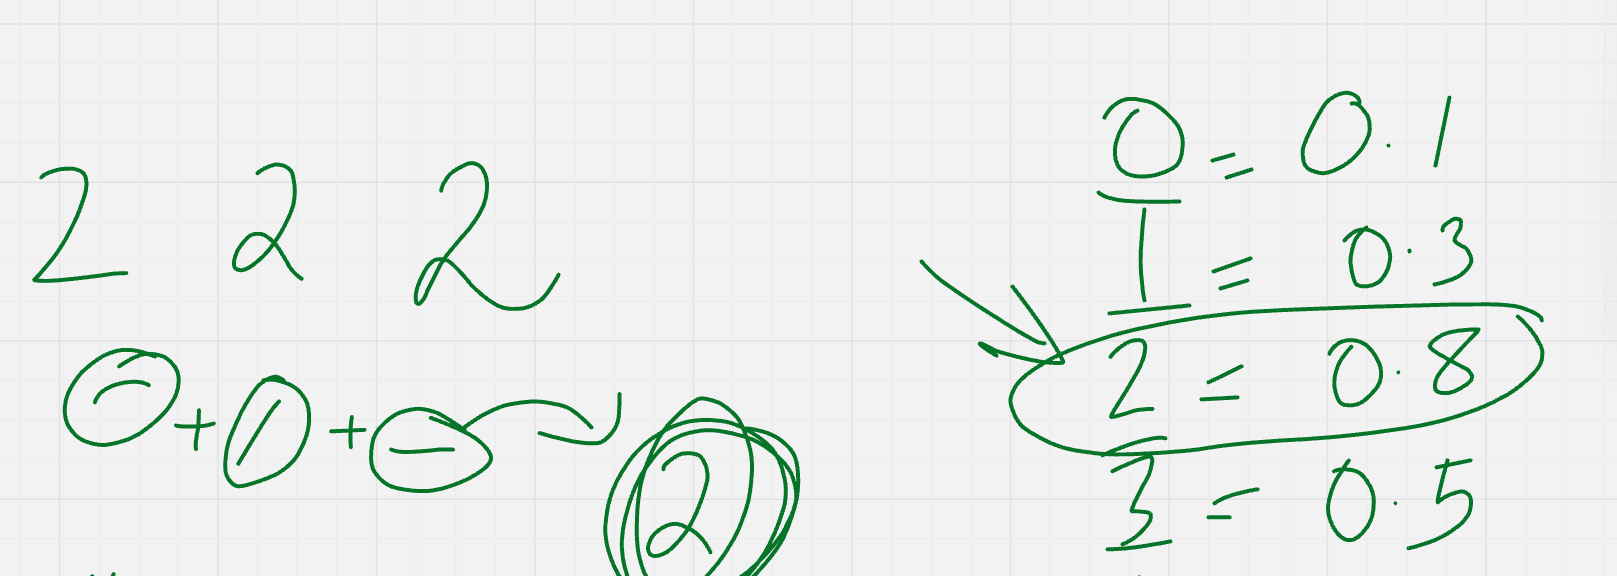

In [ ]:
#The generic pattern for a number is detected for various TYPES of 2
#whatever image us present, it will be compared to all the values in the target column and assign a probability(of it being the number)
#and the highest one is displayed

In [ ]:
x=pd.DataFrame(digits.data)
x
#1797 rows are different images(patterns)(64 pixel values from digit 0-9)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [ ]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
y=pd.DataFrame(digits.target)
y

,0
0,0
1,1
2,2
3,3
4,4
...,...
1792,9
1793,0
1794,8
1795,9


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
#Standardization : scaling down the data in a way where mean=0, std dev=1

In [ ]:
x_std=StandardScaler().fit_transform(x)
x_std

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [ ]:
x_std.shape

(1797, 64)

In [ ]:
#Transpose : convert rows to columns
#we take transpose because np.cov expects rows as features.
x1=x_std.T
x1

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.33501649, -0.33501649, -0.33501649, ..., -0.33501649,
        -0.33501649, -0.33501649],
       [-0.04308102, -1.09493684, -1.09493684, ..., -0.88456568,
        -0.67419451,  1.00877481],
       ...,
       [-1.14664746,  0.54856067,  1.56568555, ..., -0.12952258,
         0.8876023 ,  0.8876023 ],
       [-0.5056698 , -0.5056698 ,  1.6951369 , ..., -0.5056698 ,
        -0.5056698 , -0.26113572],
       [-0.19600752, -0.19600752, -0.19600752, ..., -0.19600752,
        -0.19600752, -0.19600752]])

In [ ]:
x1.shape

(64, 1797)

In [ ]:
#Covariance: tells us how features vary w.r.t each other
cov_mat=np.cov(x1)
cov_mat

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00055679,  0.55692803, ..., -0.02988686,
         0.02656195, -0.04391324],
       [ 0.        ,  0.55692803,  1.00055679, ..., -0.04120565,
         0.07263924,  0.08256908],
       ...,
       [ 0.        , -0.02988686, -0.04120565, ...,  1.00055679,
         0.64868875,  0.26213704],
       [ 0.        ,  0.02656195,  0.07263924, ...,  0.64868875,
         1.00055679,  0.62077355],
       [ 0.        , -0.04391324,  0.08256908, ...,  0.26213704,
         0.62077355,  1.00055679]])

In [ ]:
cov_mat.shape #column,column relationship

(64, 64)

In [ ]:
eig_val,eig_vec=np.linalg.eig(cov_mat)
#eigen vector: direction through which we get the max variance
#eigen value: explain the variance

In [ ]:
eig_val

array([7.34477606, 5.83549054, 5.15396118, 3.96623597, 2.9663452 ,
       2.57204442, 2.40600941, 2.06867355, 1.82993314, 1.78951739,
       1.69784616, 1.57287889, 1.38870781, 1.35933609, 1.32152536,
       1.16829176, 1.08368678, 0.99977862, 0.97438293, 0.90891242,
       0.82271926, 0.77631014, 0.71155675, 0.64552365, 0.59527399,
       0.5765018 , 0.52673155, 0.5106363 , 0.48686381, 0.45560107,
       0.44285155, 0.42230086, 0.3991063 , 0.39110111, 0.36094517,
       0.34860306, 0.3195963 , 0.05037444, 0.29406627, 0.27692285,
       0.06328961, 0.258273  , 0.24783029, 0.2423566 , 0.07635394,
       0.08246812, 0.09018543, 0.09840876, 0.10250434, 0.11188655,
       0.11932898, 0.12426371, 0.13321081, 0.14311427, 0.217582  ,
       0.15818474, 0.16875236, 0.20799593, 0.17612894, 0.2000909 ,
       0.18983516, 0.        , 0.        , 0.        ])

In [ ]:
eig_vec

array([[ 0.        ,  0.        ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.18223392, -0.04702701,  0.02358821, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.285868  , -0.0595648 , -0.05679875, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.103198  ,  0.24261778, -0.02227952, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.1198106 ,  0.16508926,  0.10036559, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07149362,  0.07132924,  0.09244589, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
len(eig_val)

64

In [ ]:
len(eig_vec)

64

In [ ]:
total=sum(eig_val)

In [ ]:
total

np.float64(61.03396436525629)

In [ ]:
#Variance explained by one/each component in percent
#list of percentage variance explained by each principal component

In [ ]:
var_exp=[]
for i in eig_val:
  percentage=(i/total)*100
  var_exp.append(percentage)

In [ ]:
var_exp

[np.float64(12.033916097734904),
 np.float64(9.561054403097883),
 np.float64(8.444414892624566),
 np.float64(6.498407907524167),
 np.float64(4.860154875966403),
 np.float64(4.214119869271944),
 np.float64(3.9420828035674003),
 np.float64(3.3893809246383264),
 np.float64(2.998221011625232),
 np.float64(2.9320025512522068),
 np.float64(2.781805463550326),
 np.float64(2.5770550925819995),
 np.float64(2.2753033157642486),
 np.float64(2.227179739514353),
 np.float64(2.1652294318492435),
 np.float64(1.9141666064421259),
 np.float64(1.7755470851681938),
 np.float64(1.6380692742844212),
 np.float64(1.5964601688623428),
 np.float64(1.4891911870878194),
 np.float64(1.3479695658179378),
 np.float64(1.2719313702347599),
 np.float64(1.1658373505919493),
 np.float64(1.0576465985363224),
 np.float64(0.9753159471981139),
 np.float64(0.9445589897319981),
 np.float64(0.8630138269707229),
 np.float64(0.8366428536685183),
 np.float64(0.7976932484112456),
 np.float64(0.7464713709260611),
 np.float64(0.7255

In [ ]:
cum_sum_var=np.cumsum(var_exp)

In [ ]:
cum_sum_var

array([ 12.0339161 ,  21.5949705 ,  30.03938539,  36.5377933 ,
        41.39794818,  45.61206805,  49.55415085,  52.94353177,
        55.94175279,  58.87375534,  61.6555608 ,  64.23261589,
        66.50791921,  68.73509895,  70.90032838,  72.81449499,
        74.59004207,  76.22811135,  77.82457152,  79.3137627 ,
        80.66173227,  81.93366364,  83.09950099,  84.15714759,
        85.13246353,  86.07702252,  86.94003635,  87.77667921,
        88.57437245,  89.32084382,  90.04642598,  90.73833722,
        91.39224576,  92.03303833,  92.62442244,  93.19558485,
        93.71922165,  93.80175675,  94.28356433,  94.73728359,
        94.84097932,  95.26414208,  95.67019515,  96.06727995,
        96.1923807 ,  96.32749911,  96.4752618 ,  96.63649786,
        96.80444425,  96.98776275,  97.18327518,  97.38687281,
        97.60512967,  97.83961267,  98.19610598,  98.45528092,
        98.73177018,  99.07255736,  99.36113266,  99.68896799,
       100.        , 100.        , 100.        , 100.  

In [ ]:
# var_exp -> helps you see the contribution of each PC
# cum_sum_var -> helps you decide how many PCs to keep

# Example: if first 2 PCs explain almsot 90% variance, you don't need the rest

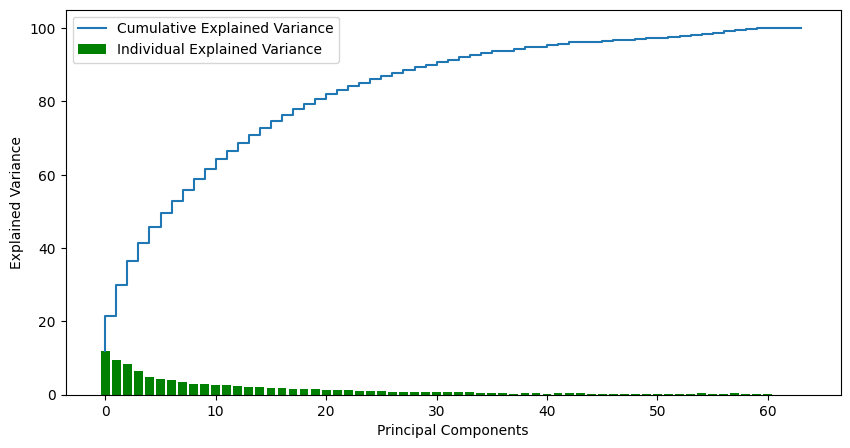

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(range(len(var_exp)), var_exp, label='Individual Explained Variance', color='g')
plt.step(range(len(cum_sum_var)), cum_sum_var, label="Cumulative Explained Variance")
plt.ylabel("Explained Variance")
plt.xlabel("Principal Components")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=25)
pca_x=pca.fit_transform(x_std)

In [ ]:
pca_x.shape

(1797, 25)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(pca_x,y,train_size=0.8,random_state=23)

In [ ]:
x_train.shape, x_test.shape

((1437, 25), (360, 25))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(random_state=23)

dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=23)

In [ ]:
predict=dt.predict(x_test)
predict

array([4, 6, 5, 8, 5, 4, 0, 5, 4, 5, 6, 4, 8, 7, 8, 5, 1, 9, 5, 0, 3, 4,
       2, 1, 4, 9, 8, 1, 3, 2, 8, 7, 8, 3, 8, 5, 3, 3, 4, 5, 4, 9, 0, 4,
       1, 2, 7, 6, 5, 5, 2, 7, 3, 3, 8, 6, 9, 2, 1, 9, 5, 5, 3, 1, 6, 7,
       6, 8, 5, 5, 4, 2, 5, 8, 9, 7, 5, 4, 6, 0, 1, 0, 5, 4, 6, 8, 2, 2,
       5, 4, 2, 5, 1, 5, 1, 1, 3, 8, 9, 9, 2, 9, 8, 8, 4, 4, 6, 1, 2, 1,
       8, 0, 3, 2, 4, 6, 5, 9, 6, 2, 9, 1, 3, 4, 1, 4, 0, 9, 7, 4, 2, 0,
       1, 1, 4, 8, 4, 6, 5, 0, 7, 6, 3, 5, 9, 4, 3, 4, 9, 7, 3, 7, 8, 3,
       2, 1, 5, 7, 7, 6, 2, 0, 0, 4, 1, 2, 6, 7, 5, 1, 2, 5, 7, 6, 5, 9,
       5, 9, 3, 2, 8, 9, 0, 7, 9, 2, 2, 8, 9, 8, 6, 7, 0, 1, 4, 7, 1, 3,
       0, 6, 1, 5, 4, 5, 2, 2, 6, 6, 9, 7, 8, 1, 8, 6, 1, 8, 0, 3, 8, 5,
       8, 3, 3, 1, 3, 4, 0, 6, 4, 1, 5, 1, 5, 9, 0, 6, 9, 7, 6, 8, 1, 0,
       9, 9, 9, 1, 1, 3, 9, 3, 9, 5, 7, 3, 5, 1, 3, 3, 9, 4, 8, 5, 9, 5,
       8, 9, 1, 7, 2, 5, 6, 0, 8, 8, 8, 6, 8, 0, 2, 3, 7, 0, 2, 0, 0, 4,
       7, 7, 6, 5, 2, 9, 2, 8, 2, 9, 0, 4, 2, 0, 9,

In [ ]:
y_test

,0
1754,4
880,6
25,5
1067,8
176,5
...,...
1299,2
1045,6
274,8
1473,6


In [ ]:
#Create a dataframe and compare your y_test and predict
df = pd.DataFrame({'Actual': y_test[0], 'Predicted': predict})

df

,Actual,Predicted
1754,4,4
880,6,6
25,5,5
1067,8,8
176,5,5
...,...,...
1299,2,3
1045,6,6
274,8,5
1473,6,6


In [ ]:
from sklearn.metrics import *

accuracy_score(y_test,predict)

#giving large number of columns causes overfitting, so
# PCA helps with retaining max variance within minimum columns

0.8111111111111111

In [ ]:
#Can we plot feature vs accuracy to visually understand their correlation